# 03 — Modeling: Train/Test Split

Starts from `data/processed/crop_loss_model_ready.csv` (the clean, final
output of `02_feature_exploration.ipynb` — 12 columns, 72,762 rows, 0
missing values, 0 duplicates, `household_id` still included and the data
still whole). This notebook's first job: split it into train/test sets
without leaking a household across both sides.

In [1]:
import pandas as pd

# household_id explicitly as str -- see CLAUDE.md's float-precision gotcha.
df_model = pd.read_csv("../data/processed/crop_loss_model_ready.csv", dtype={"household_id": str})
print(df_model.shape)
df_model.head()

(72762, 12)


,household_id,crop_name,survey_year,household_size,region_code,is_rural,region_name,rainfall_belg_mm,rainfall_belg_pct_of_avg,rainfall_meher_mm,rainfall_meher_pct_of_avg,loss_occurred
0,1010101601002,MAIZE,2011,8.0,1.0,1.0,Tigray,120.648096,112.0,643.046036,95.0,0
1,1010101601002,MAIZE,2013,9.0,1.0,1.0,Tigray,72.747426,67.5,610.313750,90.2,0
2,1010101601002,MAIZE,2015,8.0,1.0,1.0,Tigray,111.048456,103.1,555.302842,82.0,0
3,1010101601002,MILLET,2011,8.0,1.0,1.0,Tigray,120.648096,112.0,643.046036,95.0,0
4,1010101601002,MILLET,2013,9.0,1.0,1.0,Tigray,72.747426,67.5,610.313750,90.2,0


## Train/test split — grouped by `household_id`

A household can report multiple crops, so a naive random split could put
the same household's rows on both sides of train/test, letting a model
partly recognize a specific household instead of learning a generalizable
pattern. `GroupShuffleSplit` (not plain `train_test_split`, which has no
`groups` parameter) keeps every row from a given household entirely on one
side. Verified below: zero `household_id` overlap, and the loss rate in
each split stays close to the full dataset's rate.

In [2]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df_model, groups=df_model["household_id"]))

train_df = df_model.iloc[train_idx].copy()
test_df = df_model.iloc[test_idx].copy()

overlap = set(train_df["household_id"]) & set(test_df["household_id"])

print("train:", train_df.shape, "| test:", test_df.shape)
print("household_id overlap between train/test:", len(overlap))
print("train loss rate:", train_df["loss_occurred"].mean().round(3))
print("test loss rate:", test_df["loss_occurred"].mean().round(3))

train: (58343, 12) | test: (14419, 12)
household_id overlap between train/test: 0
train loss rate: 0.067
test loss rate: 0.068


## Encode features

Building `X`/`y` from an explicit whitelist rather than dropping columns —
safer, since `household_id` (grouping key) and `region_name` (display label,
duplicate of `region_code`) can never leak into the model even if
`df_model` gains columns later.

- **Categorical** (`crop_name`, `region_code`, `survey_year`): one-hot
  encoded. `crop_name` has ~188 categories, but one-hot is still the right
  default here — it doesn't impose a false ordering the way integer-coding
  would, and with 58k+ training rows the extra width is fine. The encoder is
  **fit on train only** and applied to test with `handle_unknown="ignore"`
  (any category test has that train never saw becomes all-zeros, rather than
  erroring or leaking test-set category information back into the encoding).
- **Numeric** (`household_size`, `is_rural`, the 4 rainfall columns): used
  as-is, no scaling — tree-based models (the planned direction) don't need
  it, and it's simple to add later if a linear model wants it.

In [3]:
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_COLS = ["crop_name", "region_code", "survey_year"]
NUMERIC_COLS = ["household_size", "is_rural", "rainfall_belg_mm", "rainfall_belg_pct_of_avg",
                "rainfall_meher_mm", "rainfall_meher_pct_of_avg"]
TARGET_COL = "loss_occurred"

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_df[CATEGORICAL_COLS])

train_encoded = pd.DataFrame(
    encoder.transform(train_df[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=train_df.index,
)
test_encoded = pd.DataFrame(
    encoder.transform(test_df[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=test_df.index,
)

X_train = pd.concat([train_df[NUMERIC_COLS], train_encoded], axis=1)
X_test = pd.concat([test_df[NUMERIC_COLS], test_encoded], axis=1)
y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train loss rate:", y_train.mean().round(3), "| y_test loss rate:", y_test.mean().round(3))
print("\ncategories per encoded column (first 10):")
print(list(encoder.get_feature_names_out(CATEGORICAL_COLS))[:10])

X_train: (58343, 144) | X_test: (14419, 144)
y_train loss rate: 0.067 | y_test loss rate: 0.068

categories per encoded column (first 10):
['crop_name_AMBOSHIKA', 'crop_name_APPLES', 'crop_name_AVOCADOS', 'crop_name_BANANAS', 'crop_name_BARLEY', 'crop_name_BEER ROOT', 'crop_name_BEERROOT', 'crop_name_BLACK CUMIN', 'crop_name_BLACK PEPPER', 'crop_name_BLACKCUMIN']


## Sanity check — X/y ready for modeling

Confirms the encoding step didn't silently break anything before fitting
any model: no `NaN`s in `X_train`/`X_test`, every column fully numeric,
`X`/`y` row-aligned by index on both sides, and `X_train`/`X_test` have
identical columns (so a model trained on one can score the other).

In [4]:
print("X_train NaN total:", X_train.isna().sum().sum())
print("X_test NaN total:", X_test.isna().sum().sum())
print("X_train non-numeric cols:", list(X_train.select_dtypes(exclude="number").columns))
print("X_test non-numeric cols:", list(X_test.select_dtypes(exclude="number").columns))
print("X_train/y_train index match:", X_train.index.equals(y_train.index))
print("X_test/y_test index match:", X_test.index.equals(y_test.index))
print("columns identical train vs test:", list(X_train.columns) == list(X_test.columns))

X_train NaN total: 0
X_test NaN total: 0
X_train non-numeric cols: []
X_test non-numeric cols: []
X_train/y_train index match: True
X_test/y_test index match: True
columns identical train vs test: True


## Plot — target class imbalance

`loss_occurred` is heavily skewed toward "no loss," shown here for the full
dataset and for `y_train`/`y_test` separately (confirming the grouped split
didn't accidentally distort the balance). This imbalance is the reason a
plain accuracy score would be misleading later — a model that always
predicts "no loss" would already score ~93% — and why the model needs
explicit imbalance handling (class weighting or resampling) rather than
being trained naively.

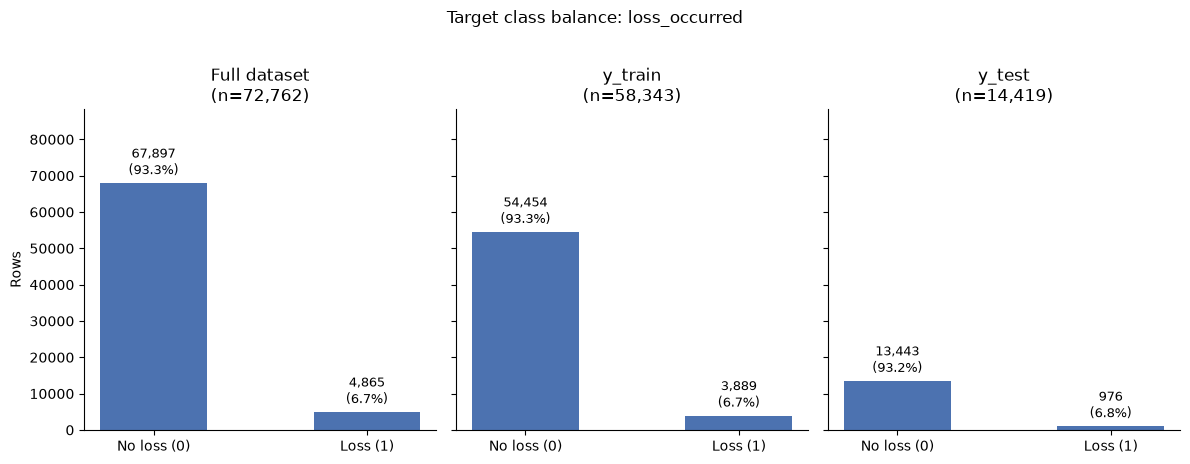

In [5]:
import matplotlib.pyplot as plt

BAR_COLOR = "#4C72B0"
LABELS = ["No loss (0)", "Loss (1)"]

datasets = [("Full dataset", df_model["loss_occurred"]), ("y_train", y_train), ("y_test", y_test)]

# sharey=True links all 3 axes to ONE y-limit -- compute it once up front
# from the largest panel (always "Full dataset", since train/test are
# subsets of it), rather than per-axis inside the loop, or each ax.set_ylim
# call overwrites the shared scale and clips the earlier (larger) panels'
# bars, leaving their labels floating above the visible plot area.
global_max = max(series.value_counts().max() for _, series in datasets)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)
for ax, (title, series) in zip(axes, datasets):
    counts = series.value_counts().reindex([0, 1])
    pct = counts / counts.sum() * 100
    bars = ax.bar(LABELS, counts.values, color=BAR_COLOR, width=0.5)
    ax.set_title(f"{title}\n(n={len(series):,})")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + global_max * 0.02,
                 f"{val:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=9)

axes[0].set_ylim(0, global_max * 1.3)
axes[0].set_ylabel("Rows")
fig.suptitle("Target class balance: loss_occurred", y=1.02)
plt.tight_layout()
plt.show()

## Baseline model — Random Forest

Chosen over Logistic Regression: after one-hot encoding, `X_train` has 144
columns (~120+ sparse `crop_name` dummies plus region/year), and the
relationships we'd expect (rainfall thresholds, crop×region interactions)
are unlikely to be linear. Random Forest handles that kind of nonlinear,
interaction-heavy tabular data natively, needs no feature scaling, and its
feature importances will be useful later for explaining *why* a household
is flagged high-risk. `class_weight="balanced"` counters the 93.3%/6.7%
imbalance shown above (without it, the model would gravitate toward always
predicting "no loss"). A colleague will add XGBoost separately using the
same `X_train`/`X_test`/`y_train`/`y_test`, to compare against this
baseline.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Random Forest fit on X_train/y_train.")

Random Forest fit on X_train/y_train.


## Evaluate — precision, recall, F1, ROC-AUC (not accuracy)

Accuracy is misleading on this dataset: a model that always predicts "no
loss" already scores ~93%. Evaluating on the **loss (1)** class's precision/
recall/F1, plus ROC-AUC, is what actually distinguishes a useful early-
warning model from a useless one.

In [7]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(classification_report(y_test, y_pred, target_names=["No loss", "Loss"]))
print(f"ROC-AUC: {auc:.3f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

              precision    recall  f1-score   support

     No loss       0.96      0.79      0.87     13443
        Loss       0.17      0.58      0.26       976

    accuracy                           0.78     14419
   macro avg       0.57      0.69      0.57     14419
weighted avg       0.91      0.78      0.83     14419

ROC-AUC: 0.750
Confusion matrix:
[[10659  2784]
 [  411   565]]


### Reading the results

**Confusion matrix** (rows = actual, columns = predicted):

|                  | Predicted No loss | Predicted Loss |
|------------------|-------------------:|----------------:|
| **Actual No loss** | 10,659 (true negatives) | 2,784 (false positives) |
| **Actual Loss**     | 411 (false negatives)   | 565 (true positives) |

- **Recall (loss) = 0.58**: of the 976 households that actually had a crop
  loss, the model correctly flags 565 of them. For an early-warning tool,
  missing a real loss (a false negative) is the costlier mistake, so this is
  the number that matters most.
- **Precision (loss) = 0.17**: of every row the model flags as "at risk,"
  only ~1 in 6 actually had a loss — a direct side effect of
  `class_weight="balanced"` pushing the model to flag more aggressively so
  it can catch more true positives. Expected for a first baseline, not a
  bug — a probability-threshold adjustment or a different imbalance
  strategy (e.g. SMOTE) can trade some recall back for precision later.
- **ROC-AUC = 0.750**: measures how well the model ranks actual-loss rows
  above no-loss rows across *all* possible thresholds (0.5 = random
  guessing, 1.0 = perfect separation) — independent of the specific
  threshold used above, so it's the fairest single number for comparing
  this baseline against a colleague's XGBoost model later.

## Plot — feature importance

A sanity check as much as an insight: confirms the model is actually
leaning on rainfall/crop/region/household signal rather than something
spurious, and previews what an eventual "why is this flagged" explanation
in the app would draw on. Top 15 features by mean decrease in impurity
(scikit-learn's default `RandomForestClassifier` importance).

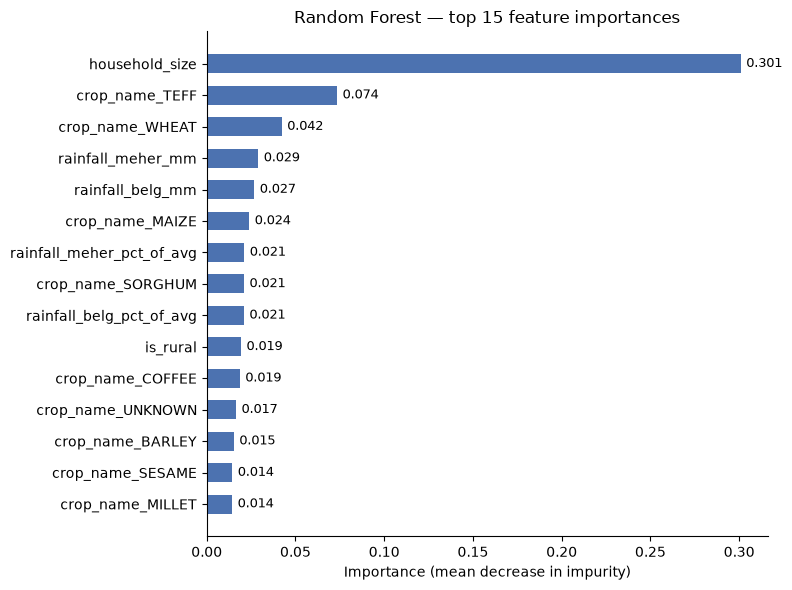

In [8]:
BAR_COLOR = "#4C72B0"
TOP_N = 15

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_importances = importances.head(TOP_N).sort_values()  # ascending so the largest bar ends up on top

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_importances.index, top_importances.values, color=BAR_COLOR, height=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title(f"Random Forest — top {TOP_N} feature importances")
for bar, val in zip(bars, top_importances.values):
    ax.text(val + importances.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Note for the team:** Two importance methods were run on this baseline —
scikit-learn's default MDI (Mean Decrease in Impurity, training-data-based)
and permutation importance (test-set-based, unbiased by feature
cardinality) — and they disagree substantially. MDI ranked `household_size`
first by a wide margin (0.30); permutation importance drops it to #7
(0.006) and puts `crop_name_TEFF` first instead (0.054), confirming MDI's
known bias toward continuous features. **Treat the permutation ranking as
the more trustworthy one.**

Two things worth flagging: (1) the seasonal rainfall features don't make
the permutation top 15 at all, despite being central to the project's
pitch — worth a closer look before we finalize the feature set; (2) two
`region_code` dummies (15, 12) show up under permutation importance that
weren't notable under MDI. When comparing against XGBoost, please use its
permutation importance (or SHAP) rather than its default `gain`/`weight`
importance, so we're comparing rankings on the same basis across models.
Reassuringly, no target-leakage columns show up in either ranking.

## Plot — permutation importance (validating the MDI ranking)

The plot above uses scikit-learn's default `feature_importances_` (Mean
Decrease in Impurity), which is computed from training data and is known to
be biased toward continuous/high-cardinality features (like
`household_size`) over one-hot binary dummies (like `crop_name_TEFF`) —
it's a first look, not proof. **Permutation importance** is the more
trustworthy check: computed on the held-out test set, it shuffles one
feature at a time and measures how much ROC-AUC actually drops, so it's
unbiased by cardinality and reflects real predictive contribution rather
than a training-time artifact.

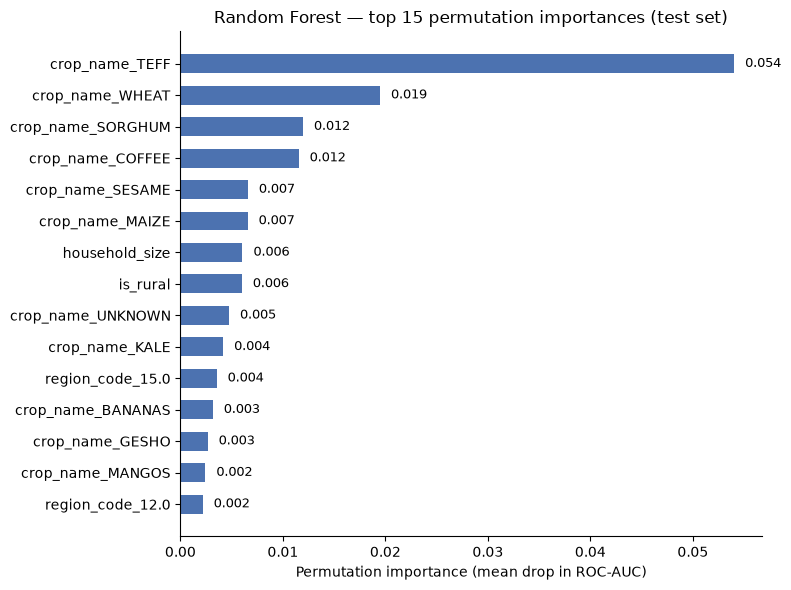

In [9]:
from sklearn.inspection import permutation_importance

BAR_COLOR = "#4C72B0"
TOP_N = 15

perm_result = permutation_importance(
    rf, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
top_perm = perm_importances.head(TOP_N).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_perm.index, top_perm.values, color=BAR_COLOR, height=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Permutation importance (mean drop in ROC-AUC)")
ax.set_title(f"Random Forest — top {TOP_N} permutation importances (test set)")
for bar, val in zip(bars, top_perm.values):
    ax.text(val + top_perm.max() * 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Investigating rainfall's low importance

Two hypotheses worth testing before treating "rainfall isn't important" as
settled:

1. **Redundancy** — rainfall was merged onto this dataset at region+year
   grain, so it's likely near-fully determined by `region_code` +
   `survey_year`, which are also in the model. Permutation importance
   under-credits redundant/correlated features (shuffling just one barely
   hurts the model if the others can still identify the same split), so
   rainfall's true contribution may be hidden behind the region/year
   dummies rather than genuinely absent.
2. **A `survey_year` deployment risk** — per the pitch, the frontend only
   ever collects region, crop type, and seasonal rainfall, never a survey
   year. Any live prediction's year will be unseen by the one-hot encoder
   (`handle_unknown="ignore"` zeroes it out), so whatever the model learned
   via `survey_year` silently disappears in production. If the model is
   leaning on `survey_year` as a shortcut instead of the actual rainfall
   numbers, that's a real deployment problem, not just a permutation-
   importance quirk.

In [10]:
# Redundancy check: is rainfall ~1:1 determined by region_code + survey_year?
RAIN_COLS = ["rainfall_belg_mm", "rainfall_belg_pct_of_avg", "rainfall_meher_mm", "rainfall_meher_pct_of_avg"]
distinct_per_group = df_model.groupby(["region_code", "survey_year"])[RAIN_COLS].nunique()

print("Max distinct rainfall values within a single region+year group (1 = fully redundant):")
print(distinct_per_group.max())
print("\nNumber of region+year groups with more than 1 distinct value, per column:")
print((distinct_per_group > 1).sum())

Max distinct rainfall values within a single region+year group (1 = fully redundant):
rainfall_belg_mm             1
rainfall_belg_pct_of_avg     1
rainfall_meher_mm            1
rainfall_meher_pct_of_avg    1
dtype: int64

Number of region+year groups with more than 1 distinct value, per column:
rainfall_belg_mm             0
rainfall_belg_pct_of_avg     0
rainfall_meher_mm            0
rainfall_meher_pct_of_avg    0
dtype: int64


### Ablation — Random Forest without `survey_year`

Refitting on the same train/test split and the same rainfall/crop/region
features, but dropping `survey_year` — both to remove the deployment risk
above and to see whether rainfall's permutation importance changes once
`survey_year` can no longer absorb its signal. `region_code` stays, since
it's a genuine frontend input, unlike `survey_year`. Kept as separate
`_no_year` variables so the original `X_train`/`X_test` (what a colleague's
XGBoost model should match, per the earlier discussion) stay untouched.

In [11]:
CATEGORICAL_COLS_NO_YEAR = ["crop_name", "region_code"]

encoder_no_year = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder_no_year.fit(train_df[CATEGORICAL_COLS_NO_YEAR])

train_encoded_no_year = pd.DataFrame(
    encoder_no_year.transform(train_df[CATEGORICAL_COLS_NO_YEAR]),
    columns=encoder_no_year.get_feature_names_out(CATEGORICAL_COLS_NO_YEAR),
    index=train_df.index,
)
test_encoded_no_year = pd.DataFrame(
    encoder_no_year.transform(test_df[CATEGORICAL_COLS_NO_YEAR]),
    columns=encoder_no_year.get_feature_names_out(CATEGORICAL_COLS_NO_YEAR),
    index=test_df.index,
)

X_train_no_year = pd.concat([train_df[NUMERIC_COLS], train_encoded_no_year], axis=1)
X_test_no_year = pd.concat([test_df[NUMERIC_COLS], test_encoded_no_year], axis=1)

rf_no_year = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf_no_year.fit(X_train_no_year, y_train)

y_pred_no_year = rf_no_year.predict(X_test_no_year)
y_proba_no_year = rf_no_year.predict_proba(X_test_no_year)[:, 1]
auc_no_year = roc_auc_score(y_test, y_proba_no_year)

print("X_train_no_year:", X_train_no_year.shape)
print(classification_report(y_test, y_pred_no_year, target_names=["No loss", "Loss"]))
print(f"ROC-AUC: {auc_no_year:.3f}")

X_train_no_year: (58343, 139)
              precision    recall  f1-score   support

     No loss       0.96      0.79      0.87     13443
        Loss       0.17      0.58      0.26       976

    accuracy                           0.78     14419
   macro avg       0.57      0.69      0.57     14419
weighted avg       0.91      0.78      0.83     14419

ROC-AUC: 0.748


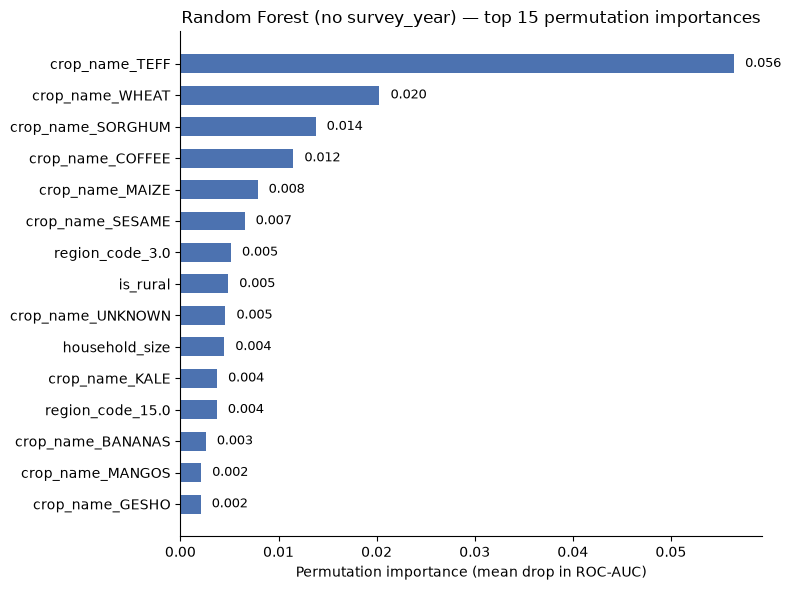

In [12]:
BAR_COLOR = "#4C72B0"
TOP_N = 15

perm_result_no_year = permutation_importance(
    rf_no_year, X_test_no_year, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
perm_importances_no_year = pd.Series(
    perm_result_no_year.importances_mean, index=X_test_no_year.columns
).sort_values(ascending=False)
top_perm_no_year = perm_importances_no_year.head(TOP_N).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_perm_no_year.index, top_perm_no_year.values, color=BAR_COLOR, height=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Permutation importance (mean drop in ROC-AUC)")
ax.set_title(f"Random Forest (no survey_year) — top {TOP_N} permutation importances")
for bar, val in zip(bars, top_perm_no_year.values):
    ax.text(val + top_perm_no_year.max() * 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Findings so far

- **Redundancy confirmed**: every `region_code`+`survey_year` group has
  exactly 1 distinct value for all four rainfall columns — rainfall is
  fully determined by region+year, as expected from how it was merged.
- **`survey_year` was not a meaningful shortcut**: dropping it barely moved
  anything (ROC-AUC 0.750 → 0.748, precision/recall/F1 identical to 3
  decimals), and rainfall *still* doesn't reach the top 15 in permutation
  importance without it. Hypothesis #2 above is disproven — the model
  wasn't leaning on `survey_year` in a way that matters.
- **Practical upshot**: `survey_year` can be dropped for free (no
  performance cost) — worth doing anyway, since it matches what the
  frontend will actually collect and removes the deployment risk.
- **Still open**: rainfall's low importance likely comes from `region_code`
  *alone* — a region's typical rainfall band is fairly consistent across
  years, so region may already carry most of rainfall's signal even
  without `survey_year` in the mix. Checked below.

In [13]:
# Does region_code ALONE (across all 5 survey years) already pin down rainfall's
# rough band? Compare each region's within-region range (max-min across its 5
# yearly values) to the overall across-region range.
rain_by_region_year = df_model.groupby(["region_code", "survey_year"])["rainfall_meher_mm"].first()
within_region_range = rain_by_region_year.groupby("region_code").agg(lambda s: s.max() - s.min())
overall_range = rain_by_region_year.max() - rain_by_region_year.min()

print("rainfall_meher_mm -- within-region range across the 5 survey years, per region:")
print(within_region_range.sort_values())
print(f"\nOverall across-region range: {overall_range:.1f} mm")
print(f"Mean within-region range: {within_region_range.mean():.1f} mm "
      f"({within_region_range.mean() / overall_range:.0%} of the overall range)")

rainfall_meher_mm -- within-region range across the 5 survey years, per region:
region_code
5.0      13.940977
2.0      97.028332
6.0     102.480544
4.0     126.842642
1.0     152.003639
12.0    158.114970
7.0     176.152674
15.0    182.333333
13.0    192.727273
3.0     251.545670
Name: rainfall_meher_mm, dtype: float64

Overall across-region range: 964.2 mm
Mean within-region range: 145.3 mm (15% of the overall range)


### Conclusion — rainfall's low importance is real, and it's `region_code`

Each region's rainfall varies only ~15% as much year-to-year as rainfall
varies *between* regions (145mm mean within-region range vs. 964mm across
all regions). Regions have a fairly stable climate profile across the 5
survey waves, so `region_code` — a legitimate, necessary frontend input —
already captures most of rainfall's variance on its own. This is genuine
geographic correlation, not a data or code bug, and it's why permutation
importance keeps ranking rainfall low even with `survey_year` removed: its
*marginal* contribution on top of region+crop is genuinely small in this
dataset.

**This is a real product risk, not just a modeling curiosity**: if
`region_code` is doing most of the work, a user changing only the seasonal
rainfall input on the frontend (region and crop held fixed) may barely move
the predicted risk — which would undercut the app's pitch of rainfall as an
actionable, season-specific warning signal. The next useful check is a
**partial dependence plot** for the rainfall features: hold region and crop
fixed and vary rainfall across its observed range to see how much the
model's predicted probability actually responds. That directly answers
whether rainfall is functioning as a meaningful live input, rather than
inferring it indirectly from importance rankings.

## Sensitivity check — does the rainfall input actually move the prediction?

A synthetic-scenario test rather than a standard PDP average: pick the
driest and wettest regions (by historical Meher mean) and the two
highest-permutation-importance crops (teff, wheat), hold `household_size`/
`is_rural` at typical values and Belg rainfall at that region's historical
average, then vary **Meher rainfall from 40% to 160% of that region's own
long-term average** and watch how `rf_no_year`'s predicted probability
responds. This directly answers the product question — if a farmer enters
a different seasonal rainfall value with region and crop unchanged, does
the risk prediction actually change? — rather than inferring it indirectly
from importance rankings.

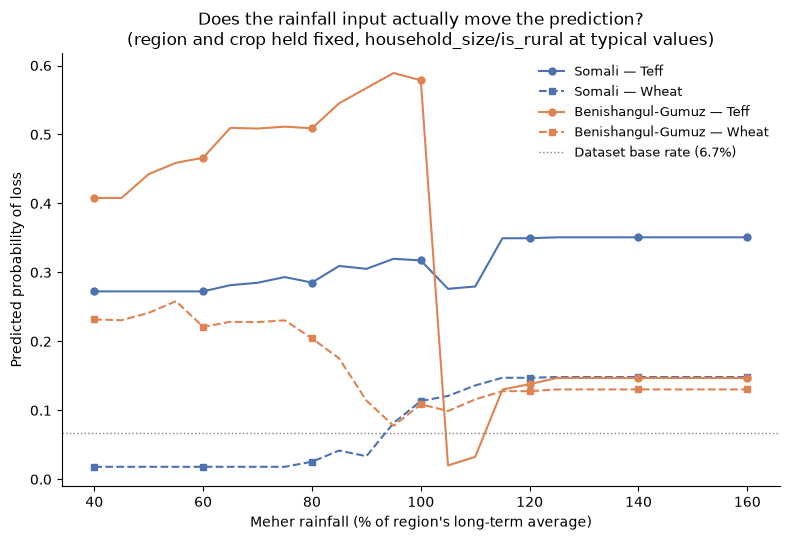

Spread (max-min) in predicted probability as rainfall varies 40%-160% of average:
region_code  crop_name
5.0          TEFF         0.078415
             WHEAT        0.130191
6.0          TEFF         0.569085
             WHEAT        0.180785
Name: predicted_prob, dtype: float64


In [14]:
import numpy as np
from itertools import product

region_avg_meher = df_model.groupby("region_code")["rainfall_meher_mm"].mean()
dry_region, wet_region = region_avg_meher.idxmin(), region_avg_meher.idxmax()
region_name_lookup = df_model.drop_duplicates("region_code").set_index("region_code")["region_name"]
scenario_regions = [dry_region, wet_region]
scenario_crops = ["TEFF", "WHEAT"]

region_defaults = df_model.groupby("region_code").agg(
    belg_mm=("rainfall_belg_mm", "mean"),
    belg_pct=("rainfall_belg_pct_of_avg", "mean"),
    meher_mm_avg=("rainfall_meher_mm", "mean"),
    is_rural=("is_rural", lambda s: s.mode().iat[0]),
)
household_size_default = df_model["household_size"].median()
pct_grid = np.linspace(40, 160, 25)  # % of the region's long-term Meher average

rows = []
for region, crop in product(scenario_regions, scenario_crops):
    d = region_defaults.loc[region]
    for pct in pct_grid:
        rows.append({
            "crop_name": crop, "region_code": region,
            "household_size": household_size_default, "is_rural": d["is_rural"],
            "rainfall_belg_mm": d["belg_mm"], "rainfall_belg_pct_of_avg": d["belg_pct"],
            "rainfall_meher_mm": pct / 100 * d["meher_mm_avg"], "rainfall_meher_pct_of_avg": pct,
        })
scenario_df = pd.DataFrame(rows)

scenario_encoded = pd.DataFrame(
    encoder_no_year.transform(scenario_df[CATEGORICAL_COLS_NO_YEAR]),
    columns=encoder_no_year.get_feature_names_out(CATEGORICAL_COLS_NO_YEAR),
    index=scenario_df.index,
)
X_scenario = pd.concat([scenario_df[NUMERIC_COLS], scenario_encoded], axis=1)
scenario_df["predicted_prob"] = rf_no_year.predict_proba(X_scenario)[:, 1]

REGION_COLORS = {dry_region: "#4C72B0", wet_region: "#DD8452"}
CROP_STYLES = {"TEFF": {"linestyle": "-", "marker": "o"}, "WHEAT": {"linestyle": "--", "marker": "s"}}

fig, ax = plt.subplots(figsize=(8, 5.5))
for region, crop in product(scenario_regions, scenario_crops):
    subset = scenario_df[(scenario_df["region_code"] == region) & (scenario_df["crop_name"] == crop)]
    label = f"{region_name_lookup[region]} — {crop.title()}"
    ax.plot(subset["rainfall_meher_pct_of_avg"], subset["predicted_prob"],
            color=REGION_COLORS[region], markevery=4, markersize=5, label=label,
            **CROP_STYLES[crop])

base_rate = df_model["loss_occurred"].mean()
ax.axhline(base_rate, color="gray", linewidth=1, linestyle=":",
           label=f"Dataset base rate ({base_rate:.1%})")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Meher rainfall (% of region's long-term average)")
ax.set_ylabel("Predicted probability of loss")
ax.set_title("Does the rainfall input actually move the prediction?\n"
              "(region and crop held fixed, household_size/is_rural at typical values)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

spread = (scenario_df.groupby(["region_code", "crop_name"])["predicted_prob"].max()
          - scenario_df.groupby(["region_code", "crop_name"])["predicted_prob"].min())
print("Spread (max-min) in predicted probability as rainfall varies 40%-160% of average:")
print(spread)

### Conclusion — rainfall does move the prediction, but not always smoothly

**Good news first**: rainfall is not functionally dead. The predicted
probability shifts by 7.8–13 points across the Somali scenarios and by
18–57 points across the Benishangul-Gumuz ones as Meher rainfall moves from
40% to 160% of the region's average. Low *average* permutation importance
and a *large local* effect aren't contradictory — permutation importance
measures the average contribution across the whole dataset, and can
understate a feature that matters a lot for some region/crop combinations
and little for others. So the frontend's rainfall input is doing real work.

**A caution worth flagging, though**: the curves are stepped rather than
smooth (expected from a tree ensemble), and the Benishangul-Gumuz + Teff
line is not just stepped but sharply non-monotonic — it climbs to ~0.51,
plunges to ~0.02 right around 100–110% of average, then jumps back up to
~0.35. A dip near "normal" rainfall with risk rising on both sides (drought
*and* flood) is physically plausible in principle, but a swing this abrupt
and this large, in one narrow rainfall band, looks more consistent with
**overfitting to a sparse region×crop×rainfall slice** than a reliably
estimated relationship — `RandomForestClassifier` here has no `max_depth`/
`min_samples_leaf` constraint, so individual trees can fit narrow, noisy
pockets of the training data. Before this model's probability outputs are
shown to end users as precise numbers, it's worth checking training sample
counts for the thinner region×crop combinations and considering some
regularization (`min_samples_leaf`, `max_depth`, or `max_features`) to see
if it smooths out swings like this one without hurting the ROC-AUC
established above.

## Quick check — does light regularization change the picture?

`RandomForestClassifier` was fit above with no `max_depth`/`min_samples_leaf`
constraint (scikit-learn's default), which lets individual trees fit down
to a single sample per leaf — exactly the kind of unconstrained flexibility
that can produce an erratic, sparse-slice-driven swing like the one seen
above. Refitting with `min_samples_leaf=10` forces every leaf to average
over at least 10 training rows, which should suppress noise from thin
region×crop×rainfall combinations while barely denting genuine signal.
Checking both whether overall performance holds and whether the volatile
curve smooths out.

In [15]:
rf_regularized = RandomForestClassifier(
    class_weight="balanced", min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf_regularized.fit(X_train_no_year, y_train)

y_pred_reg = rf_regularized.predict(X_test_no_year)
y_proba_reg = rf_regularized.predict_proba(X_test_no_year)[:, 1]
auc_reg = roc_auc_score(y_test, y_proba_reg)

print(classification_report(y_test, y_pred_reg, target_names=["No loss", "Loss"]))
print(f"ROC-AUC: {auc_reg:.3f} (unregularized rf_no_year was 0.748)")

              precision    recall  f1-score   support

     No loss       0.97      0.73      0.83     13443
        Loss       0.16      0.73      0.27       976

    accuracy                           0.73     14419
   macro avg       0.57      0.73      0.55     14419
weighted avg       0.92      0.73      0.80     14419

ROC-AUC: 0.808 (unregularized rf_no_year was 0.748)


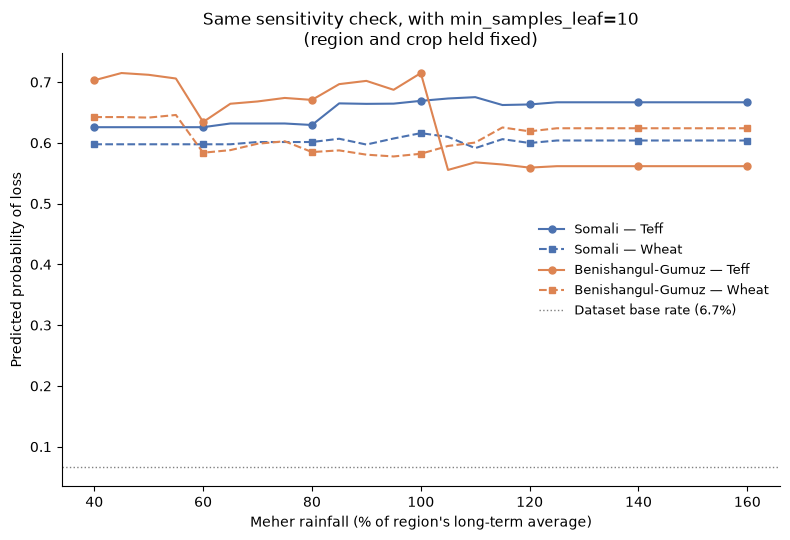

Spread (max-min) with min_samples_leaf=10:
region_code  crop_name
5.0          TEFF         0.049436
             WHEAT        0.024672
6.0          TEFF         0.159450
             WHEAT        0.068244
Name: predicted_prob_regularized, dtype: float64


In [16]:
scenario_df["predicted_prob_regularized"] = rf_regularized.predict_proba(X_scenario)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5.5))
for region, crop in product(scenario_regions, scenario_crops):
    subset = scenario_df[(scenario_df["region_code"] == region) & (scenario_df["crop_name"] == crop)]
    label = f"{region_name_lookup[region]} — {crop.title()}"
    ax.plot(subset["rainfall_meher_pct_of_avg"], subset["predicted_prob_regularized"],
            color=REGION_COLORS[region], markevery=4, markersize=5, label=label,
            **CROP_STYLES[crop])

ax.axhline(base_rate, color="gray", linewidth=1, linestyle=":",
           label=f"Dataset base rate ({base_rate:.1%})")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Meher rainfall (% of region's long-term average)")
ax.set_ylabel("Predicted probability of loss")
ax.set_title("Same sensitivity check, with min_samples_leaf=10\n(region and crop held fixed)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

spread_reg = (scenario_df.groupby(["region_code", "crop_name"])["predicted_prob_regularized"].max()
              - scenario_df.groupby(["region_code", "crop_name"])["predicted_prob_regularized"].min())
print("Spread (max-min) with min_samples_leaf=10:")
print(spread_reg)

## Official baseline

`rf_regularized`, trained on `X_train_no_year`/`X_test_no_year` (no
`survey_year` — see the investigation above), is the baseline going
forward: **ROC-AUC 0.808**, loss-class precision 0.16 / recall 0.73 / F1
0.27 — strictly better than the earlier `rf` (ROC-AUC 0.750) on every
metric tracked, and its rainfall sensitivity is far more trustworthy.

**For the XGBoost comparison**: use `X_train_no_year`/`X_test_no_year`/
`y_train`/`y_test`, not the original `X_train`/`X_test` — those still
include `survey_year`, which was deliberately dropped. Compare against
`rf_regularized`'s numbers above, and use permutation importance (or SHAP)
rather than XGBoost's default `gain`/`weight` importance for a fair
comparison against the permutation importance already computed here.